# PCA-HVG baseline ST embeddings

simplest possible ST encoder: raw counts -> normalize -> HVG selection -> PCA(50).
tissue-agnostic, no pretrained model, no graph structure.

serves two purposes:
1. ablation baseline for Novae in alignment experiments (is GNN spatial structure helping?)
2. fallback for subarrays excluded from Novae (TNBC55: 196 median genes)

output: 50-d per-spot embeddings. alignment MLP: Linear(50, 512) -> GELU -> Linear(512, 512)
(no LayerNorm needed - PCA output is centered and scaled by construction).

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
import subprocess
import io
from pathlib import Path
from scipy.sparse import csr_matrix

ROOT = Path().resolve().parents[1]
DATA = ROOT / 'data' / 'inputs'
by_array = DATA / 'byArray'

sns.set_theme(style='ticks', palette='Dark2', context='notebook')

## 1. load raw counts

all 5 subarrays - including TNBC55 which was excluded from Novae (196 median genes).
PCA-HVG works on whatever genes are present, no minimum threshold.

In [14]:
SELECTED_SUBARRAYS = [
    ('TNBC55', 'CN28', 'C1'),
    ('TNBC3', 'CN2', 'C1'),
    ('TNBC68', 'CN34', 'D2'),
    ('TNBC83', 'CN42', 'C1'),
    ('TNBC1', 'CN1', 'C1'),
]

def load_selection_rdata(slide, position):
    """load raw counts and spot coordinates from selection.RData via Rscript."""
    rdata_path = by_array / slide / position / 'selection.RData'
    assert rdata_path.exists(), f'missing: {rdata_path}'
    r = subprocess.run(['Rscript', '-e', f'load(\"{rdata_path}\"); write.csv(cnts, stdout())'],
                       capture_output=True, text=True)
    assert r.returncode == 0, f'Rscript failed: {r.stderr[:200]}'
    counts = pd.read_csv(io.StringIO(r.stdout), index_col=0)
    r2 = subprocess.run(['Rscript', '-e', f'load(\"{rdata_path}\"); write.csv(spots, stdout())'],
                        capture_output=True, text=True)
    coords = pd.read_csv(io.StringIO(r2.stdout), index_col=0)
    return counts, coords

all_counts = {}
all_coords = {}
for tnbc_id, slide, pos in SELECTED_SUBARRAYS:
    key = f'{tnbc_id}_{slide}_{pos}'
    counts, coords = load_selection_rdata(slide, pos)
    all_counts[key] = counts
    all_coords[key] = coords
    genes_detected = (counts > 0).sum(axis=1)
    print(f'{key}: {counts.shape[0]} spots x {counts.shape[1]} genes, median genes/spot={genes_detected.median():.0f}')

print(f'\ntotal spots: {sum(c.shape[0] for c in all_counts.values())}')

TNBC55_CN28_C1: 542 spots x 19068 genes, median genes/spot=196
TNBC3_CN2_C1: 701 spots x 24232 genes, median genes/spot=5407
TNBC68_CN34_D2: 697 spots x 21297 genes, median genes/spot=873
TNBC83_CN42_C1: 1398 spots x 26326 genes, median genes/spot=2608
TNBC1_CN1_C1: 1075 spots x 27567 genes, median genes/spot=4399

total spots: 4413


## 2. build combined AnnData

merge all subarrays into one AnnData for joint HVG selection and PCA.
joint processing ensures the PCA basis is shared across subarrays -
embeddings are directly comparable.

In [15]:
# find common gene set across all subarrays
gene_sets = [set(counts.columns) for counts in all_counts.values()]
common_genes = sorted(set.intersection(*gene_sets))
all_genes = sorted(set.union(*gene_sets))
print(f'common genes: {len(common_genes)}')
print(f'union genes: {len(all_genes)}')

# build per-subarray AnnData with common genes, then concatenate
adatas = []
for key in all_counts:
    counts = all_counts[key][common_genes]
    coords = all_coords[key]
    adata = ad.AnnData(
        X=csr_matrix(counts.values),
        obs=pd.DataFrame({'subarray': key}, index=counts.index),
        var=pd.DataFrame(index=common_genes),
    )
    adata.obsm['spatial'] = coords[['pixel_x', 'pixel_y']].values
    adatas.append(adata)

adata_all = ad.concat(adatas, join='inner')
adata_all.obs_names_make_unique()
print(f'\ncombined: {adata_all.n_obs} spots x {adata_all.n_vars} genes')

common genes: 15215
union genes: 34617

combined: 4413 spots x 15215 genes


## 3. preprocessing and HVG selection

standard scanpy workflow: normalize total -> log1p -> highly variable genes.
keep raw counts in a layer for reference.

In [16]:
# save raw counts
adata_all.layers['counts'] = adata_all.X.copy()

# normalize
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)

# HVG selection - use batch_key to find genes variable within subarrays, not between
sc.pp.highly_variable_genes(adata_all, n_top_genes=2000, batch_key='subarray')
n_hvg = adata_all.var['highly_variable'].sum()
print(f'HVGs selected: {n_hvg}')

# check HVG overlap with TNBC55 (196 median genes - will it have enough HVGs?)
tnbc55_mask = adata_all.obs['subarray'] == 'TNBC55_CN28_C1'
tnbc55_expressed = (adata_all[tnbc55_mask].X.toarray() > 0).mean(axis=0) > 0.01
hvg_mask = adata_all.var['highly_variable'].values
hvg_in_tnbc55 = (hvg_mask & tnbc55_expressed).sum()
print(f'HVGs expressed in TNBC55: {hvg_in_tnbc55}/{n_hvg} ({100*hvg_in_tnbc55/n_hvg:.0f}%)')

HVGs selected: 2000
HVGs expressed in TNBC55: 1320/2000 (66%)


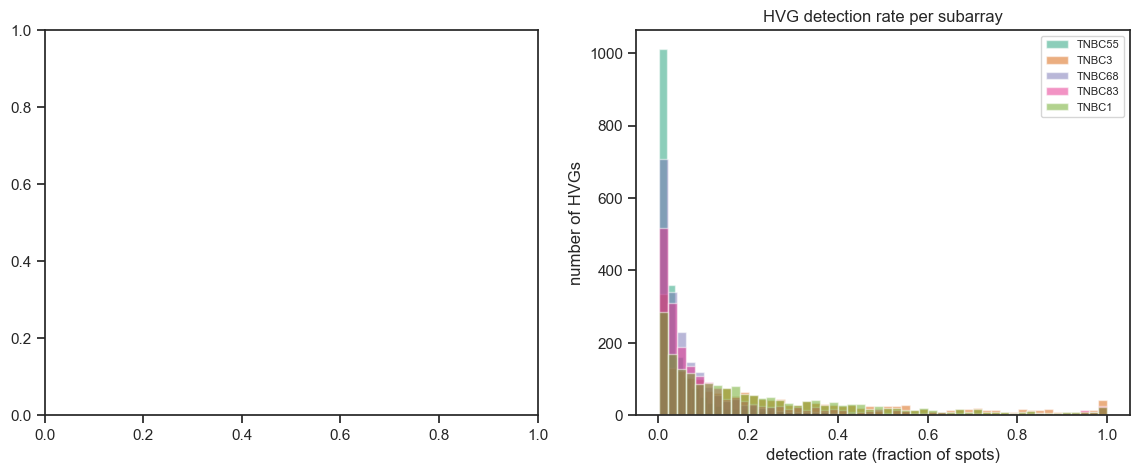

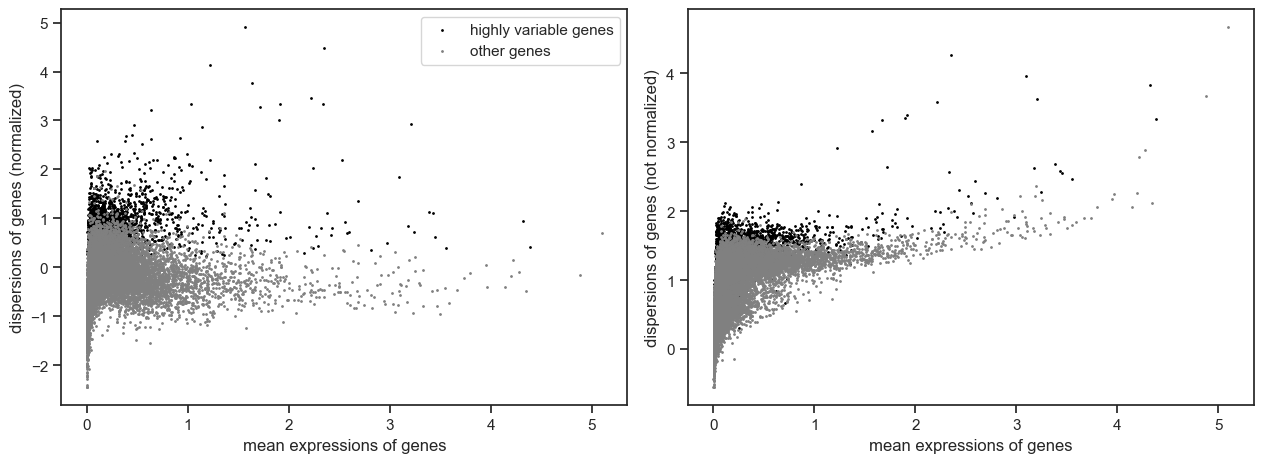

In [17]:
# visualize HVG selection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# mean-variance plot
sc.pl.highly_variable_genes(adata_all, show=False)

# per-subarray gene detection rates for HVGs
detection_rates = {}
for key in all_counts:
    mask = adata_all.obs['subarray'] == key
    sub = adata_all[mask][:, adata_all.var['highly_variable']]
    rate = (sub.X.toarray() > 0).mean(axis=0)
    detection_rates[key] = rate
    short_key = key.split('_')[0]
    axes[1].hist(rate, bins=50, alpha=0.5, label=short_key)

axes[1].set_xlabel('detection rate (fraction of spots)')
axes[1].set_ylabel('number of HVGs')
axes[1].set_title('HVG detection rate per subarray')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. PCA

50 components on HVGs. this is the baseline ST embedding.

PCA variance explained (50 components): 16.8%
  50% variance in 51 components
  80% variance in 51 components
  90% variance in 51 components
  95% variance in 51 components


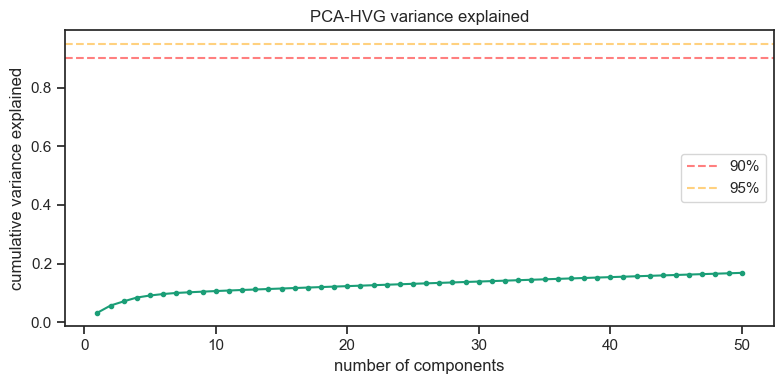

In [18]:
# subset to HVGs, scale, PCA
adata_hvg = adata_all[:, adata_all.var['highly_variable']].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, random_state=42)

# variance explained
cumvar = np.cumsum(adata_hvg.uns['pca']['variance_ratio'])
print(f'PCA variance explained (50 components): {cumvar[-1]*100:.1f}%')
for thresh in [0.50, 0.80, 0.90, 0.95]:
    rank = np.searchsorted(cumvar, thresh) + 1
    print(f'  {thresh:.0%} variance in {rank} components')

# plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 51), cumvar, 'o-', markersize=3)
ax.axhline(0.90, color='red', ls='--', alpha=0.5, label='90%')
ax.axhline(0.95, color='orange', ls='--', alpha=0.5, label='95%')
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative variance explained')
ax.set_title('PCA-HVG variance explained')
ax.legend()
plt.tight_layout()
plt.show()

## 5. quality checks

same battery as UNI2 and Novae for direct comparison:
- within/between patient similarity gap
- spatial autocorrelation (Spearman rho)
- UMAP colored by patient

In [19]:
# extract per-subarray embeddings
embeddings_all = adata_hvg.obsm['X_pca']  # (n_spots, 50)
labels_all = adata_hvg.obs['subarray'].values

all_embeddings = {}
for key in all_counts:
    mask = labels_all == key
    all_embeddings[key] = embeddings_all[mask]
    print(f'{key}: {all_embeddings[key].shape}')

print(f'\ntotal: {embeddings_all.shape}')

TNBC55_CN28_C1: (542, 50)
TNBC3_CN2_C1: (701, 50)
TNBC68_CN34_D2: (697, 50)
TNBC83_CN42_C1: (1398, 50)
TNBC1_CN1_C1: (1075, 50)

total: (4413, 50)


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

rng = np.random.RandomState(42)

# within/between patient gap
n_sample = min(500, len(embeddings_all))
idx = rng.choice(len(embeddings_all), size=n_sample, replace=False)
sub_emb = embeddings_all[idx]
sub_labels = labels_all[idx]
cos = cosine_similarity(sub_emb)
triu = np.triu_indices(n_sample, k=1)
same = sub_labels[triu[0]] == sub_labels[triu[1]]

within = cos[triu][same].mean()
between = cos[triu][~same].mean()
gap = within - between

print(f'within-patient cosine sim:  {within:.4f}')
print(f'between-patient cosine sim: {between:.4f}')
print(f'gap: {gap:.4f}')
print(f'\ncomparison:')
print(f'  UNI2 raw:   gap=0.138')
print(f'  Novae:      gap=0.022 (batch correction active)')
print(f'  PCA-HVG:    gap={gap:.3f}')

within-patient cosine sim:  0.5276
between-patient cosine sim: -0.1434
gap: 0.6710

comparison:
  UNI2 raw:   gap=0.138
  Novae:      gap=0.022 (batch correction active)
  PCA-HVG:    gap=0.671


In [21]:
# spatial autocorrelation per subarray
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

print('spatial autocorrelation (Spearman rho, distance vs 1-cosine):')
print(f'{"subarray":<25} {"rho":>10} {"p-value":>12}')
print('-' * 50)

rhos = []
for key in all_embeddings:
    emb = all_embeddings[key]
    mask = labels_all == key
    coords = adata_hvg[mask].obsm['spatial']

    n = min(300, len(emb))
    sub_idx = rng.choice(len(emb), size=n, replace=False)

    phys_dist = pdist(coords[sub_idx])
    emb_dist = pdist(emb[sub_idx], metric='cosine')

    rho, pval = spearmanr(phys_dist, emb_dist)
    rhos.append(rho)
    print(f'{key:<25} {rho:>10.3f} {pval:>12.2e}')

print(f'\nmean rho: {np.mean(rhos):.3f}')
print(f'\ncomparison:')
print(f'  UNI2 raw:   mean rho ~ -0.413')
print(f'  Novae:      mean rho ~ -0.380')
print(f'  PCA-HVG:    mean rho = {np.mean(rhos):.3f}')

spatial autocorrelation (Spearman rho, distance vs 1-cosine):
subarray                         rho      p-value
--------------------------------------------------
TNBC55_CN28_C1                 0.488     0.00e+00
TNBC3_CN2_C1                   0.256     0.00e+00
TNBC68_CN34_D2                 0.098     5.11e-97
TNBC83_CN42_C1                 0.301     0.00e+00
TNBC1_CN1_C1                   0.261     0.00e+00

mean rho: 0.281

comparison:
  UNI2 raw:   mean rho ~ -0.413
  Novae:      mean rho ~ -0.380
  PCA-HVG:    mean rho = 0.281


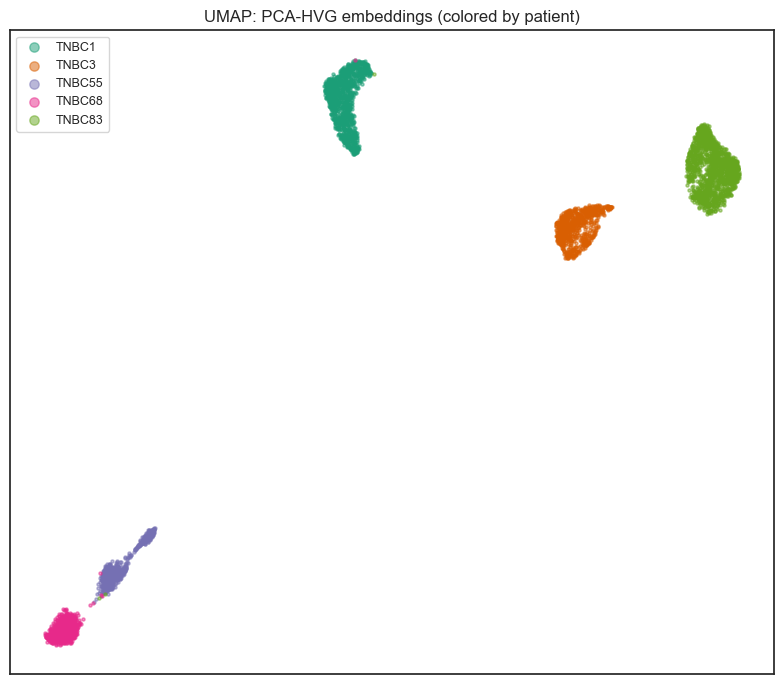

In [22]:
# UMAP
import warnings
warnings.filterwarnings('ignore', message='.*n_jobs.*')
import umap

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
umap_emb = reducer.fit_transform(embeddings_all)

unique_labels = sorted(set(labels_all))
colors = sns.color_palette('Dark2', len(unique_labels))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(8, 7))
for label in unique_labels:
    mask = labels_all == label
    short = label.split('_')[0]
    ax.scatter(umap_emb[mask, 0], umap_emb[mask, 1],
               c=[label_to_color[label]], s=5, alpha=0.5, label=short)
ax.set_title('UMAP: PCA-HVG embeddings (colored by patient)', fontsize=12)
ax.legend(markerscale=3, fontsize=9)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. save embeddings

In [23]:
import json

out_dir = ROOT / 'data' / 'embeddings' / 'pca_hvg'
out_dir.mkdir(parents=True, exist_ok=True)

# per-subarray
for key, emb in all_embeddings.items():
    np.save(out_dir / f'{key}.npy', emb)

# stacked
np.save(out_dir / 'all_embeddings.npy', embeddings_all)
np.save(out_dir / 'all_labels.npy', labels_all)

# save HVG list and PCA loadings for reproducibility
hvg_names = adata_hvg.var_names.tolist()
pca_loadings = adata_hvg.varm['PCs']  # (n_hvg, 50)
np.save(out_dir / 'pca_loadings.npy', pca_loadings)
np.save(out_dir / 'pca_mean.npy', adata_hvg.var['mean'].values)  # for centering new data
np.save(out_dir / 'pca_std.npy', adata_hvg.var['std'].values)    # for scaling new data

meta = {
    'n_hvgs': int(n_hvg),
    'n_components': 50,
    'variance_explained': float(cumvar[-1]),
    'subarrays': list(all_embeddings.keys()),
    'n_common_genes': len(common_genes),
    'hvg_selection': 'scanpy, n_top_genes=2000, batch_key=subarray',
    'normalization': 'normalize_total(1e4) + log1p + scale(max_value=10)',
}
with open(out_dir / 'pca_hvg_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

# save HVG list
with open(out_dir / 'hvg_genes.txt', 'w') as f:
    f.write('\n'.join(hvg_names))

print(f'saved to {out_dir.relative_to(ROOT)}')
for fp in sorted(out_dir.iterdir()):
    print(f'  {fp.name} ({fp.stat().st_size / 1024:.0f} KB)')

saved to data/embeddings/pca_hvg
  TNBC1_CN1_C1.npy (210 KB)
  TNBC3_CN2_C1.npy (137 KB)
  TNBC55_CN28_C1.npy (106 KB)
  TNBC68_CN34_D2.npy (136 KB)
  TNBC83_CN42_C1.npy (273 KB)
  all_embeddings.npy (862 KB)
  all_labels.npy (9 KB)
  hvg_genes.txt (36 KB)
  pca_hvg_meta.json (0 KB)
  pca_loadings.npy (781 KB)
  pca_mean.npy (16 KB)
  pca_std.npy (16 KB)


## 7. summary

In [24]:
print('=== PCA-HVG baseline summary ===')
print(f'spots: {embeddings_all.shape[0]}')
print(f'embedding dim: {embeddings_all.shape[1]}')
print(f'HVGs: {n_hvg}')
print(f'variance explained (50 PCs): {cumvar[-1]*100:.1f}%')
print(f'patient gap: {gap:.4f}')
print(f'mean spatial rho: {np.mean(rhos):.3f}')
print(f'\ncomparison table:')
print(f'{"encoder":<15} {"dim":>5} {"eff. rank":>10} {"gap":>8} {"mean rho":>10}')
print('-' * 52)
print(f'{"UNI2 raw":<15} {1536:>5} {"~50":>10} {0.138:>8.3f} {-0.413:>10.3f}')
print(f'{"UNI2 reinhard":<15} {1536:>5} {"~50":>10} {0.132:>8.3f} {"~-0.39":>10}')
print(f'{"Novae":<15} {64:>5} {"~11-14":>10} {0.022:>8.3f} {-0.380:>10.3f}')
print(f'{"PCA-HVG":<15} {50:>5} {"50":>10} {gap:>8.3f} {np.mean(rhos):>10.3f}')
print(f'\noutput: data/embeddings/pca_hvg/')
print(f'\nnext: alignment experiment template')

=== PCA-HVG baseline summary ===
spots: 4413
embedding dim: 50
HVGs: 2000
variance explained (50 PCs): 16.8%
patient gap: 0.6710
mean spatial rho: 0.281

comparison table:
encoder           dim  eff. rank      gap   mean rho
----------------------------------------------------
UNI2 raw         1536        ~50    0.138     -0.413
UNI2 reinhard    1536        ~50    0.132     ~-0.39
Novae              64     ~11-14    0.022     -0.380
PCA-HVG            50         50    0.671      0.281

output: data/embeddings/pca_hvg/

next: alignment experiment template
